# Heat risk triage — data, model and evaluation

The analytical record behind the pipeline. Every figure here is computed by
importing the pipeline modules; nothing is reimplemented, because logic that
exists only in a notebook drifts out of step with the scripts and cannot be
trusted. The scripts are the source of truth.

Run order before this notebook: `generate_data.py`, `extract.py`, `model.py`,
`retrieve.py`, `validate.py`.

In [1]:
%matplotlib inline

import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")

import config
import extract
import features
import model
import validate

pd.set_option("display.width", 120)
print(f"fleet: {config.N_ASSETS} assets, {config.N_HISTORICAL_EVENTS} historical events")
print(f"extraction model: {config.EXTRACTION_MODEL}")

fleet: 900 assets, 16 historical events
extraction model: gemini-3.5-flash-lite


## 1. Data generation

`generate_data.py` writes the fleet, the weather, the hidden failure process and
the inspection notes, then asserts six hard gates and writes the measured value
of each to `output/data_checks.txt`. A gate failure stops the build rather than
being worked around.

The gates exist to stop the synthetic world being either implausible or too easy:
gate 2 is the project's central premise, gate 4 keeps mild events near
failure-free, and gate 6 stops the failure label being a deterministic read-off
of hidden condition.

In [2]:
print((config.OUTPUT_DIR / "data_checks.txt").read_text())

Hard gates on generated data
ageing reference temperature in force: 38.0 C

[PASS] 1. realised failure rate
         measured: 0.0113
         required in [0.008, 0.013]
[PASS] 2. long-moderate stress exceeds short-severe
         measured: long-moderate 0.95 vs short-severe 0.71 equivalent days
         long-moderate must be strictly greater (equivalent days at reference)
[PASS] 3. non-zero stress share on heat events
         measured: 0.9877
         required >= 0.8
[PASS] 4. mild event failure rate
         measured: 0.0019
         required < 0.002
[PASS] 5. degree-hours vs peak temperature correlation
         measured: 0.4961
         required < 0.85
[PASS] 6. failures in below-median condition assets
         measured: 0.2086 (34 of 163 failures)
         required >= 0.2



In [3]:
assets = features.load_assets()
events = features.load_events()
hourly = features.load_hourly()
outcomes = features.load_outcomes()
inspections = features.load_inspections()

historical = events[~events["is_scenario"]]
print(f"training rows: {len(outcomes):,}  failures: {outcomes['failed'].sum():,}"
      f"  base rate: {outcomes['failed'].mean():.4f}")
print(f"inspection notes: {len(inspections):,}")
assets.head()

training rows: 14,400  failures: 163  base rate: 0.0113
inspection notes: 1,800


,asset_id,name,district,lat,lon,install_year,rated_capacity_mva,cooling_type,peak_load_pct,customers_served,criticality,last_maintenance_date,prior_heat_faults
0,SUB-SGW-001,Camden Landing 69/12kV,Northfield,38.8089,-121.3358,1987,10,OFAF,0.686,1117,2,2024-12-13,1
1,SUB-SGW-002,Marlow Bend 69/12kV,Cedar Basin,38.4586,-121.2250,1979,10,ONAF,0.762,679,5,2025-05-24,1
2,SUB-SGW-003,Zeller Vale 69/12kV,Ridgeline,38.4883,-121.5521,1978,10,ONAF,0.633,1076,3,2025-05-02,0
3,SUB-SGW-004,Granite Bluff 69/12kV,Junction West,38.6442,-121.6820,1978,10,ONAF,0.763,990,2,2025-09-07,0
4,SUB-SGW-005,Westmarch Grove 230/34kV,Northfield,38.7607,-121.3970,2001,100,ONAN,0.570,2565,3,2024-03-17,0


## 2. Exploratory analysis

The premise the whole project rests on is that accumulated exposure matters more
than peak temperature. The first plot is the test of it: long moderate events
peak lower than short severe ones and still do more damage.

Note what the model is *not* given. It sees ambient temperature, the asset
register and the four extracted flags. It never sees core temperature, the
thermal time constant, or the latent condition that actually generated the
outcomes.

In [4]:
by_event = (outcomes.merge(events[["event_id", "event_type", "peak_temp_c", "duration_days"]],
                           on="event_id")
            .groupby(["event_id", "event_type", "peak_temp_c", "duration_days"], as_index=False)
            .agg(failures=("failed", "sum"), rate=("failed", "mean")))
by_event.sort_values("failures", ascending=False)

,event_id,event_type,peak_temp_c,duration_days,failures,rate
1,EVT-02,long-severe,40.79,5,50,0.055556
6,EVT-07,long-severe,39.39,5,28,0.031111
9,EVT-10,long-severe,39.09,5,24,0.026667
2,EVT-03,long-moderate,36.85,6,12,0.013333
11,EVT-12,long-moderate,36.66,5,10,0.011111
4,EVT-05,long-moderate,36.65,5,9,0.010000
3,EVT-04,short-severe,41.55,2,5,0.005556
5,EVT-06,short-severe,41.72,2,5,0.005556
14,EVT-15,long-moderate,35.71,5,5,0.005556
7,EVT-08,short-severe,40.19,2,4,0.004444


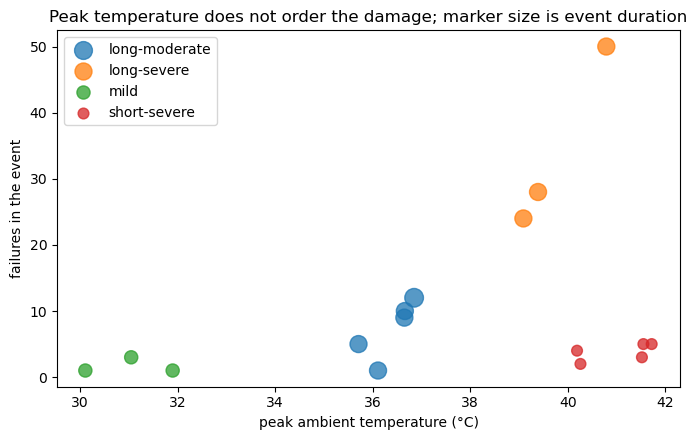

In [5]:
# Peak temperature against failures, marker size by duration. If peak alone
# drove risk, the short-severe points on the right would sit highest.
fig, ax = plt.subplots(figsize=(7, 4.5))
for event_type, group in by_event.groupby("event_type"):
    ax.scatter(group["peak_temp_c"], group["failures"],
               s=group["duration_days"] * 30, label=event_type, alpha=0.75)
ax.set_xlabel("peak ambient temperature (°C)")
ax.set_ylabel("failures in the event")
ax.set_title("Peak temperature does not order the damage; marker size is event duration")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
summary = by_event.groupby("event_type").agg(
    events=("event_id", "count"),
    mean_peak=("peak_temp_c", "mean"),
    mean_days=("duration_days", "mean"),
    failures=("failures", "sum"),
    rate=("rate", "mean"),
).sort_values("mean_peak")
print(summary.round(4))
print()
print("Short-severe events peak highest and cause fewest failures per event;")
print("long-moderate events peak lower and cause more. That is the premise.")

               events  mean_peak  mean_days  failures    rate
event_type                                                   
mild                3    31.0200        3.0         5  0.0019
long-moderate       5    36.3960        5.2        37  0.0082
long-severe         3    39.7567        5.0       102  0.0378
short-severe        5    41.0480        2.0        19  0.0042

Short-severe events peak highest and cause fewest failures per event;
long-moderate events peak lower and cause more. That is the premise.


### Why: overnight recovery sets the floor, not a failure to reset

Oil temperature lags ambient by a few hours. Over an eight-hour night a unit
sheds most of its offset — at the fast end of the modelled range, 96% of it. It
substantially *does* reset. What the overnight minimum sets is the floor it
resets to: a night at 27°C rather than 18°C starts the next day nine degrees
hotter, so each day reaches a higher peak from a higher base.

Because insulation ageing is Arrhenius and irreversible, five days of elevated
temperature does five days of damage that the weather breaking does not return.
That is why `thermal_stress` is accumulated equivalent ageing, and why
`max_overnight_min_c` and `consecutive_warm_nights` are features.

In [7]:
for tau in [config.TAU_MIN_HOURS, config.TAU_MEAN_HOURS, config.TAU_MAX_HOURS]:
    remaining = (1 - 1 / tau) ** 8
    print(f"tau {tau:.0f} h: {remaining:6.3f} of the offset remains after 8 h "
          f"({100 * (1 - remaining):.0f}% reset)")

tau 3 h:  0.039 of the offset remains after 8 h (96% reset)
tau 5 h:  0.168 of the offset remains after 8 h (83% reset)
tau 8 h:  0.344 of the offset remains after 8 h (66% reset)


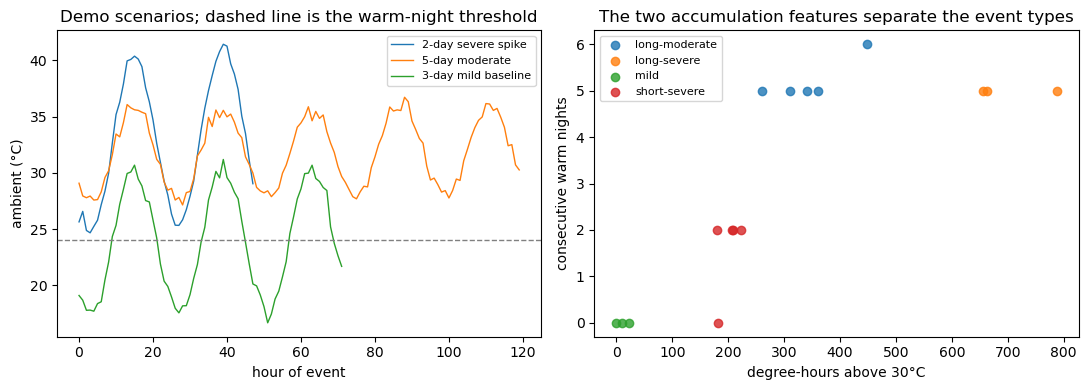

In [8]:
hazard_table = features.build_hazard_table(events, hourly)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for scenario_id, label, *_ in config.SCENARIOS:
    temps = hourly.loc[hourly["event_id"] == scenario_id].sort_values("hour_index")["temp_c"]
    axes[0].plot(range(len(temps)), temps.to_numpy(), label=label, linewidth=1)
axes[0].axhline(config.WARM_NIGHT_C, linestyle="--", color="grey", linewidth=1)
axes[0].set_xlabel("hour of event")
axes[0].set_ylabel("ambient (°C)")
axes[0].set_title("Demo scenarios; dashed line is the warm-night threshold")
axes[0].legend(fontsize=8)

hz = hazard_table.merge(events[["event_id", "event_type", "is_scenario"]], on="event_id")
for event_type, group in hz[~hz["is_scenario"]].groupby("event_type"):
    axes[1].scatter(group["degree_hours_above_30"], group["consecutive_warm_nights"],
                    label=event_type, alpha=0.8)
axes[1].set_xlabel("degree-hours above 30°C")
axes[1].set_ylabel("consecutive warm nights")
axes[1].set_title("The two accumulation features separate the event types")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Feature relationships

Some pairs are collinear by construction and that is expected rather than a
problem at this size: `peak_temp_c` and `max_overnight_min_c` both derive from
the same diurnal curve, and `age_years` and `days_since_maintenance` both track
how long an asset has been neglected. L2 regularisation handles the redundancy;
what matters is that no feature is a proxy for the hidden state, which
`validate.py` checks separately.

`hours_above_35` and `event_duration_days` were deliberately excluded as
collinear with `degree_hours_above_30`.

In [9]:
extractions = extract.load_extractions(inspections)
flags = features.asset_condition_flags(extractions)
pairs, labels, groups = features.training_pairs(outcomes)
X_frame = features.build_feature_matrix(assets, hazard_table, flags, pairs)
X = X_frame.to_numpy()

assert list(X_frame.columns) == config.FEATURES
print(f"feature matrix: {X_frame.shape[0]:,} rows x {X_frame.shape[1]} columns")
X_frame.describe().T[["mean", "std", "min", "max"]].round(3)

feature matrix: 14,400 rows x 13 columns


,mean,std,min,max
peak_temp_c,38.031,3.768,29.952,42.200
degree_hours_above_30,303.449,227.354,0.000,787.220
max_overnight_min_c,26.016,4.694,17.323,32.451
consecutive_warm_nights,3.062,2.193,0.000,6.000
age_years,32.504,10.683,3.000,57.000
cooling_type_ordinal,0.794,0.759,0.000,2.000
peak_load_pct,0.755,0.113,0.550,0.950
days_since_maintenance,736.242,422.953,1.000,1459.000
prior_heat_faults,0.771,0.872,0.000,4.000
flag_cooling_degraded,0.384,0.486,0.000,1.000


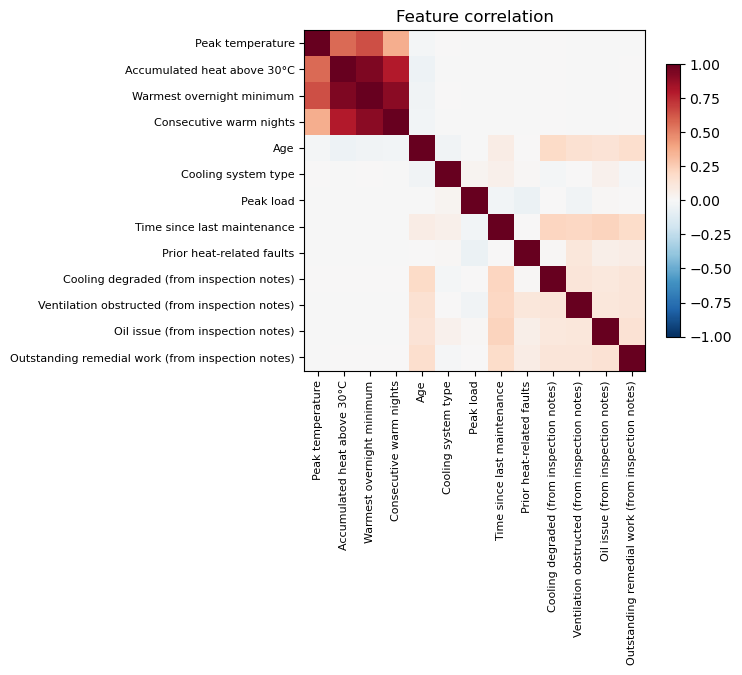

+0.933  degree_hours_above_30 / max_overnight_min_c
+0.906  max_overnight_min_c / consecutive_warm_nights
+0.794  degree_hours_above_30 / consecutive_warm_nights
+0.642  peak_temp_c / max_overnight_min_c
+0.563  peak_temp_c / degree_hours_above_30


In [10]:
corr = X_frame.corr()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
labels_short = [config.FEATURE_LABELS[f] for f in config.FEATURES]
ax.set_xticks(range(len(config.FEATURES)))
ax.set_xticklabels(labels_short, rotation=90, fontsize=8)
ax.set_yticks(range(len(config.FEATURES)))
ax.set_yticklabels(labels_short, fontsize=8)
ax.set_title("Feature correlation")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

pairs_high = [(config.FEATURES[i], config.FEATURES[j], corr.iloc[i, j])
              for i in range(len(config.FEATURES)) for j in range(i + 1, len(config.FEATURES))
              if abs(corr.iloc[i, j]) > 0.5]
for a, b, value in sorted(pairs_high, key=lambda t: -abs(t[2])):
    print(f"{value:+.3f}  {a} / {b}")

## 4. Extraction results

The extraction layer exists for two cases the keyword baseline cannot see: a
defect the note records as *fixed*, and a defect the note explicitly records as
*absent*. Both are false. Overall accuracy hides this, so the error breakdown is
by note category.

The baseline is deliberately naive — per-flag term lists, case-insensitive
substring match, about twenty lines. It is a comparator, not a fallback.

In [11]:
truth = pd.read_csv(config.DATA_DIR / "inspection_truth.csv")
merged, per_flag, by_category = validate.evaluate_extraction(inspections, truth, extractions)

rows = []
for flag, result in per_flag.items():
    rows.append({
        "flag": flag,
        "actual positives": result["llm"]["actual_positive"],
        "LLM precision": result["llm"]["precision"],
        "LLM recall": result["llm"]["recall"],
        "keyword precision": result["baseline"]["precision"],
        "keyword recall": result["baseline"]["recall"],
    })
pd.DataFrame(rows).round(3)

,flag,actual positives,LLM precision,LLM recall,keyword precision,keyword recall
0,cooling_degraded,380,0.922,0.958,0.652,1.000
1,ventilation_obstructed,374,0.895,0.979,0.744,1.000
2,oil_issue,407,0.875,0.963,0.702,0.725
3,overdue_remedial,390,0.855,1.000,0.826,0.826


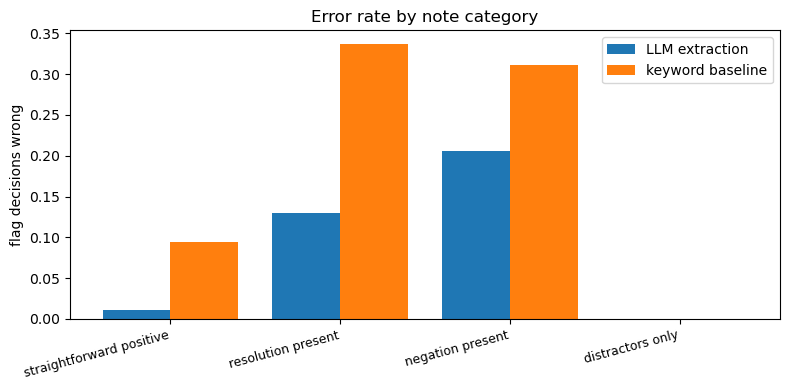

,notes,llm_errors,llm_error_rate,baseline_errors,baseline_error_rate
distractors only,644.0,0.0,0.0000,0.0,0.0000
negation present,148.0,122.0,0.2061,184.0,0.3108
resolution present,144.0,75.0,0.1302,194.0,0.3368
straightforward positive,864.0,38.0,0.0110,327.0,0.0946


In [12]:
category_order = ["straightforward positive", "resolution present",
                  "negation present", "distractors only"]
present = [c for c in category_order if c in by_category]
llm_rates = [by_category[c]["llm_error_rate"] for c in present]
base_rates = [by_category[c]["baseline_error_rate"] for c in present]

x = np.arange(len(present))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, llm_rates, width=0.4, label="LLM extraction")
ax.bar(x + 0.2, base_rates, width=0.4, label="keyword baseline")
ax.set_xticks(x)
ax.set_xticklabels(present, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("flag decisions wrong")
ax.set_title("Error rate by note category")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(by_category).T[["notes", "llm_errors", "llm_error_rate",
                             "baseline_errors", "baseline_error_rate"]].round(4)

## 5. Training

Grouped on `event_id`, not on rows. Every asset in one event shares all four
hazard features, so a random split would put the same weather on both sides of
the fold and the reported AUC would be a fiction.

`C` is checked across one decade either side of the default. It is a check, not
a search: the value is not chosen to maximise anything.

In [13]:
predictions = model.out_of_fold_predictions(X, labels, groups)
result = model.evaluate(predictions, labels, groups)
print(f"pooled out-of-fold AUC : {result['auc']:.4f}")
print(f"precision@{config.CREW_CAPACITY}         : {result['precision_at_15']:.4f}")
print(f"recall@{config.CREW_CAPACITY}            : {result['recall_at_15']:.4f}")

pooled out-of-fold AUC : 0.8261
precision@15         : 0.0792
recall@15            : 0.0609


### Pooled AUC is not the operational number

Most pairs in a pooled AUC straddle two different events — a failure in a severe
event against a survivor in a mild one — and separating those needs only "is it
hot for a long time", which requires no model. The number the ranked queue
depends on is the within-event one: given *this* forecast, does the model put the
assets that failed above the ones that did not.

In [14]:
from sklearn.metrics import roc_auc_score

within = []
for event_id in pd.unique(groups):
    mask = groups == event_id
    if 0 < labels[mask].sum() < mask.sum():
        within.append((event_id, roc_auc_score(labels[mask], predictions[mask]),
                       int(labels[mask].sum())))
within_frame = pd.DataFrame(within, columns=["event_id", "within_event_auc", "failures"])
print(f"events with any failure: {len(within_frame)} of {config.N_HISTORICAL_EVENTS}")
print(f"mean within-event AUC  : {within_frame['within_event_auc'].mean():.4f}")
within_frame.sort_values("failures", ascending=False).round(4)

events with any failure: 16 of 16
mean within-event AUC  : 0.6219


,event_id,within_event_auc,failures
1,EVT-02,0.8165,50
6,EVT-07,0.8204,28
9,EVT-10,0.8246,24
2,EVT-03,0.6190,12
11,EVT-12,0.6627,10
4,EVT-05,0.8220,9
3,EVT-04,0.4489,5
5,EVT-06,0.5917,5
14,EVT-15,0.6865,5
7,EVT-08,0.7799,4


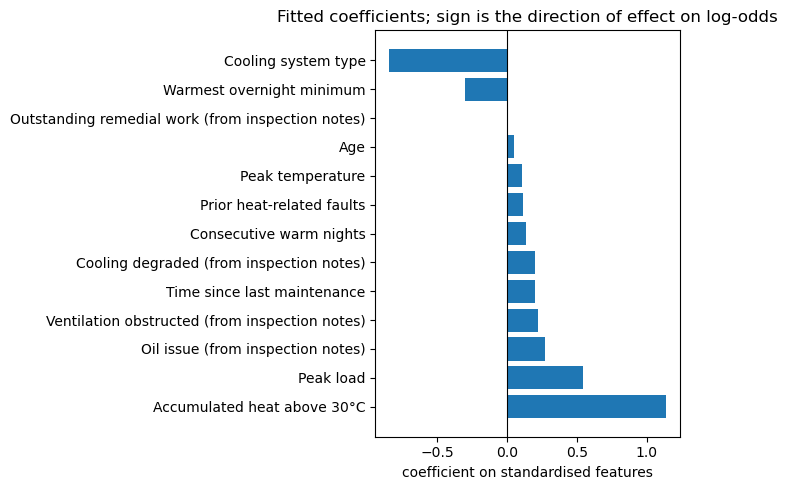

,feature,coefficient
1,Accumulated heat above 30°C,1.1381
6,Peak load,0.5426
11,Oil issue (from inspection notes),0.2712
10,Ventilation obstructed (from inspection notes),0.2197
7,Time since last maintenance,0.1981
9,Cooling degraded (from inspection notes),0.1980
3,Consecutive warm nights,0.1324
8,Prior heat-related faults,0.1144
0,Peak temperature,0.1060
4,Age,0.0533


In [15]:
metrics = json.loads((config.OUTPUT_DIR / "metrics.json").read_text())

final = model.build_model()
final.fit(X, labels)
coefficients = pd.DataFrame({
    "feature": [config.FEATURE_LABELS[f] for f in config.FEATURES],
    "coefficient": final["clf"].coef_[0],
}).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(coefficients["feature"], coefficients["coefficient"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("coefficient on standardised features")
ax.set_title("Fitted coefficients; sign is the direction of effect on log-odds")
plt.tight_layout()
plt.show()
coefficients.round(4)

In [16]:
sweep = pd.DataFrame(metrics["c_sweep"])
print("Regularisation check — recorded, not searched over:")
print(sweep.round(4).to_string(index=False))

Regularisation check — recorded, not searched over:
    C    auc
 0.01 0.8135
 0.10 0.8264
 1.00 0.8261
10.00 0.8219


## 6. Calibration

Calibration is load-bearing here because priority is `risk × customers_served` —
an expected number of customers affected. That only means anything if the
probability means what it says, which is why there is no class weighting, no
resampling and no Platt or isotonic layer on top.

The base rate is synthetic and inflated about twelvefold for trainability
(D-012), so these probabilities are calibrated to the synthetic world, not to
the real one. Ranking is unaffected, and the system consumes a ranking.

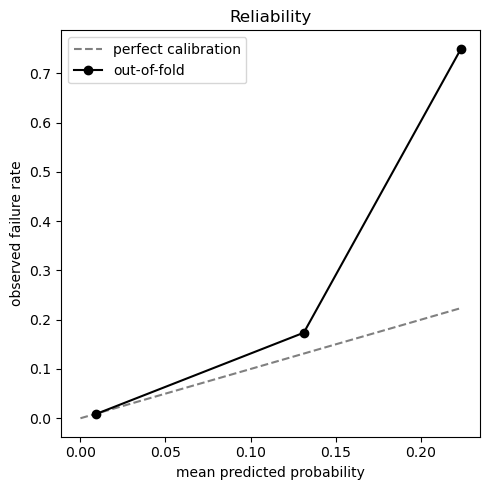

Brier, full model    : 0.01049
Brier, base rate only: 0.01119
improvement          : 0.00071


,mean_predicted,observed,count
0,0.0093,0.0088,14221
1,0.1313,0.1737,167
2,0.2237,0.7500,12


In [17]:
bins = pd.DataFrame(metrics["calibration_bins"])
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, bins["mean_predicted"].max()], [0, bins["mean_predicted"].max()],
        linestyle="--", color="grey", label="perfect calibration")
ax.plot(bins["mean_predicted"], bins["observed"], marker="o", color="black",
        label="out-of-fold")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed failure rate")
ax.set_title("Reliability")
ax.legend()
plt.tight_layout()
plt.show()

brier = metrics["brier"]
print(f"Brier, full model    : {brier['model']:.5f}")
print(f"Brier, base rate only: {brier['base_rate']:.5f}")
print(f"improvement          : {brier['improvement']:.5f}")
bins.round(4)

## 7. Ablations

Three variants through the same grouped cross-validation loop. The question the
middle row answers is whether reading the inspection notes was worth doing at
all: if "without notes" matches "full model", the extraction layer is decoration.

In [18]:
ablations = pd.DataFrame(metrics["ablations"]).T
ablations.index.name = "variant"
ablations.round(4)

,n_features,auc,precision_at_15,recall_at_15
variant,,,,
Heuristic baseline (peak temp x age),2.0,0.5830,0.0000,0.0000
Without notes,9.0,0.8223,0.0458,0.0377
Full model,13.0,0.8261,0.0792,0.0609


## 8. Error analysis

Two questions. Where did the model rank an asset highly that did not fail, and
where did an asset fail that the model ranked low? Both are expected — failure is
a Bernoulli draw, so a high-risk asset surviving is not a mistake — but the
pattern in them is informative.

In [19]:
analysis = pairs.copy()
analysis["failed"] = labels
analysis["predicted"] = predictions
analysis["event_type"] = analysis["event_id"].map(dict(zip(events["event_id"], events["event_type"])))
analysis["rank_in_event"] = analysis.groupby("event_id")["predicted"].rank(ascending=False)

top_survivors = (analysis[(analysis["rank_in_event"] <= config.CREW_CAPACITY)
                          & (analysis["failed"] == 0)]
                 .sort_values("predicted", ascending=False).head(10))
print("Highest-risk assets that did not fail:")
print(top_survivors[["asset_id", "event_id", "event_type", "predicted", "rank_in_event"]]
      .round(4).to_string(index=False))

Highest-risk assets that did not fail:
   asset_id event_id  event_type  predicted  rank_in_event
SUB-SGW-581   EVT-02 long-severe     0.2305            3.0
SUB-SGW-585   EVT-02 long-severe     0.2233            6.0
SUB-SGW-288   EVT-02 long-severe     0.2170            7.0
SUB-SGW-699   EVT-02 long-severe     0.1984           12.0
SUB-SGW-493   EVT-10 long-severe     0.1966            2.0
SUB-SGW-396   EVT-02 long-severe     0.1961           15.0
SUB-SGW-581   EVT-10 long-severe     0.1909            3.0
SUB-SGW-709   EVT-10 long-severe     0.1780            4.0
SUB-SGW-018   EVT-10 long-severe     0.1637            5.0
SUB-SGW-772   EVT-10 long-severe     0.1624            6.0


In [20]:
missed = (analysis[analysis["failed"] == 1]
          .sort_values("rank_in_event", ascending=False).head(10))
print("Failures the model ranked lowest within their event:")
print(missed[["asset_id", "event_id", "event_type", "predicted", "rank_in_event"]]
      .round(4).to_string(index=False))

Failures the model ranked lowest within their event:
   asset_id event_id    event_type  predicted  rank_in_event
SUB-SGW-887   EVT-15 long-moderate     0.0005          865.0
SUB-SGW-324   EVT-14  short-severe     0.0003          848.0
SUB-SGW-878   EVT-02   long-severe     0.0106          845.0
SUB-SGW-665   EVT-03 long-moderate     0.0017          778.0
SUB-SGW-469   EVT-02   long-severe     0.0153          777.0
SUB-SGW-469   EVT-03 long-moderate     0.0020          752.0
SUB-SGW-540   EVT-02   long-severe     0.0179          732.0
SUB-SGW-778   EVT-04  short-severe     0.0009          718.0
SUB-SGW-006   EVT-02   long-severe     0.0196          711.0
SUB-SGW-297   EVT-11          mild     0.0002          704.0


In [21]:
# What separates a missed failure from a caught one? Compare the flags and the
# register fields, using only what the model could see.
caught = analysis[(analysis["failed"] == 1) & (analysis["rank_in_event"] <= config.CREW_CAPACITY)]
missed_all = analysis[(analysis["failed"] == 1) & (analysis["rank_in_event"] > config.CREW_CAPACITY)]

comparison = []
for name, subset in [("caught in top 15", caught), ("missed", missed_all)]:
    rows = X_frame.loc[subset.index]
    comparison.append({
        "group": name,
        "n": len(subset),
        **{config.FEATURE_LABELS[f]: rows[f].mean() for f in
           ["age_years", "peak_load_pct", "days_since_maintenance", "prior_heat_faults",
            "flag_cooling_degraded", "flag_oil_issue"]},
    })
pd.DataFrame(comparison).set_index("group").round(3).T

group,caught in top 15,missed
n,19.000,144.000
Age,36.263,33.389
Peak load,0.862,0.799
Time since last maintenance,1141.474,845.486
Prior heat-related faults,1.368,0.792
Cooling degraded (from inspection notes),0.947,0.479
Oil issue (from inspection notes),1.000,0.535


Missed failures are the ones with no recorded defect and an unremarkable
register entry — nothing the model could have read told it they were at risk.
That is the honest ceiling on this design: it ranks recorded condition against
forecast stress, and an asset whose condition was never recorded is invisible to
it. Continuous telemetry would be the thing that catches those, and it is listed
as a deliberate exclusion rather than an oversight.